
# Final Project: Learning-Based Face Super-Resolution

This notebook presents a **technical** version of the project. It focuses on formal problem definition, baselines, model design, evaluation, and limitations.



## 1. Problem formulation

We study **face hallucination / face super-resolution** as a supervised learning problem.
Given a low-resolution face image $x_{lr}$, we learn a mapping:

$$f_{\theta}(x_{lr}) \approx y_{hr}$$

where $y_{hr}$ is the corresponding high-resolution target.

The optimization objective is the pixel-wise reconstruction loss:

$$\mathcal{L}(	heta) = \|f_	heta(x_{lr}) - y_{hr}\|_2^2$$


In [1]:
import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    pass
elif (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError("Open the notebook from the project root or notebook/ directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: D:\Computer_vision\Final_project_Face_Hallucination_technical\Final_project_Face_Hallucination


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_olivetti_faces

from src.baselines import make_baselines_from_hr
from src.config import COLOR_Y_CONFIG, GRAYSCALE_CONFIG, HISTORY_DIR, INPUT_DIR, METRICS_DIR
from src.inference import predict_color_from_file, predict_grayscale
from src.io_utils import load_color_images
from src.metrics import summarize_metrics
from src.models import SRCNN


## 2. Data and baselines

We use:
- **grayscale Olivetti faces** for the main controlled experiment;
- **real RGB face images** from `data/input/` for Y-channel color reconstruction.

Baseline methods:
- nearest neighbor interpolation,
- bilinear interpolation,
- bicubic interpolation.


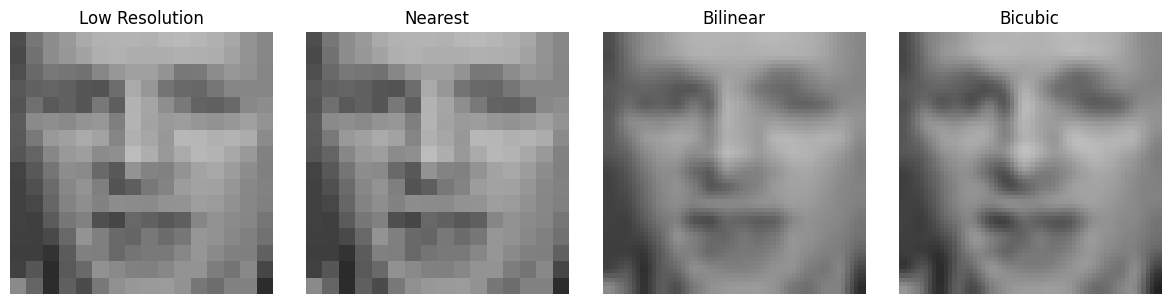

In [3]:

faces = fetch_olivetti_faces(shuffle=True, random_state=42).images.astype(np.float32)
gt = faces[0]
lr, baselines = make_baselines_from_hr(gt, lr_size=GRAYSCALE_CONFIG["lr_size"], hr_size=GRAYSCALE_CONFIG["hr_size"])

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(lr, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Low Resolution")
axes[1].imshow(baselines["nearest"], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Nearest")
axes[2].imshow(baselines["bilinear"], cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Bilinear")
axes[3].imshow(baselines["bicubic"], cmap="gray", vmin=0, vmax=1)
axes[3].set_title("Bicubic")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()



## 3. Model

We use a shallow **SRCNN** architecture. It is intentionally simple and interpretable:
- 9x9 convolution for patch extraction,
- 5x5 convolution for nonlinear mapping,
- 5x5 convolution for reconstruction.


In [4]:

model = SRCNN()
print(model)
print("Trainable parameters:", model.count_parameters())


SRCNN(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): Sigmoid()
  )
)
Trainable parameters: 57281



## 4. Training protocol

Training is intentionally kept **outside the notebook** to make experiments reproducible and avoid long notebook execution.

Run from terminal:

```bash
python -m src.train
```

This script trains:
1. grayscale SRCNN,
2. color Y-channel SRCNN,

and saves:
- checkpoints,
- training histories,
- result figures,
- metric tables.


In [5]:

print("Training is optional and is executed from CLI: python -m src.train")
print("History directory:", HISTORY_DIR)


Training is optional and is executed from CLI: python -m src.train
History directory: D:\Computer_vision\Final_project_Face_Hallucination_technical\Final_project_Face_Hallucination\outputs\history



## 5. Training curves

If training has already been executed, the history files below will show optimization dynamics and possible overfitting.


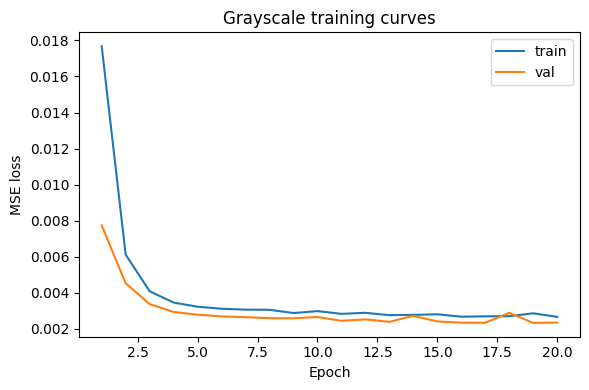

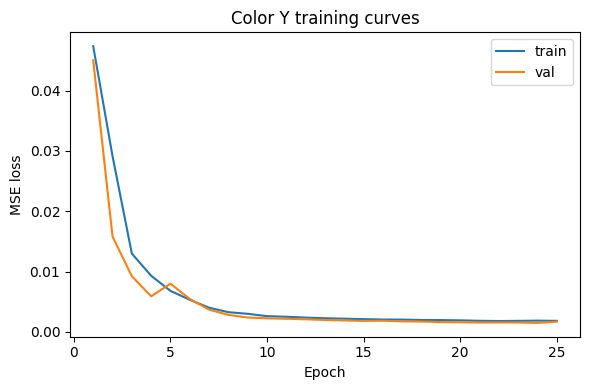

In [6]:

gray_history_path = HISTORY_DIR / "grayscale_history.csv"
color_history_path = HISTORY_DIR / "color_y_history.csv"

for title, path in [("Grayscale", gray_history_path), ("Color Y", color_history_path)]:
    if path.exists():
        df_hist = pd.read_csv(path)
        plt.figure(figsize=(6, 4))
        plt.plot(df_hist["epoch"], df_hist["train_loss"], label="train")
        plt.plot(df_hist["epoch"], df_hist["val_loss"], label="val")
        plt.title(f"{title} training curves")
        plt.xlabel("Epoch")
        plt.ylabel("MSE loss")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"History file not found: {path}")



## 6. Grayscale inference and qualitative comparison


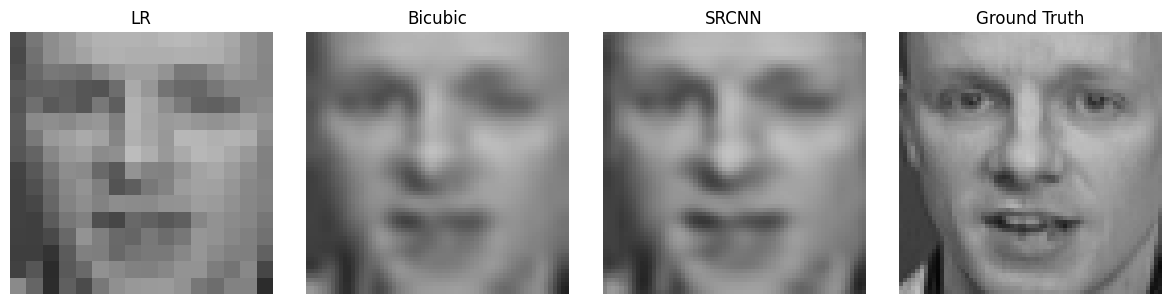

In [7]:

srcnn = predict_grayscale(gt)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(lr, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("LR")
axes[1].imshow(baselines["bicubic"], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Bicubic")
axes[2].imshow(srcnn, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("SRCNN")
axes[3].imshow(gt, cmap="gray", vmin=0, vmax=1)
axes[3].set_title("Ground Truth")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()



## 7. Error analysis

Pixel-wise metrics do not always fully reflect perceptual quality. Error maps help localize failure regions.


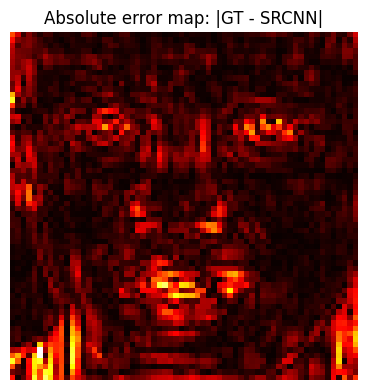

In [8]:

diff = np.abs(gt - srcnn)
plt.figure(figsize=(4, 4))
plt.imshow(diff, cmap="hot")
plt.title("Absolute error map: |GT - SRCNN|")
plt.axis("off")
plt.tight_layout()
plt.show()



## 8. Quantitative evaluation

The project stores all per-sample metrics and summary tables in `outputs/metrics/`.


In [9]:

for path in [METRICS_DIR / "grayscale_summary_metrics.csv", METRICS_DIR / "color_summary_metrics.csv"]:
    if path.exists():
        print(f"Summary metrics from: {path.name}")
        display(pd.read_csv(path))
    else:
        print(f"Metrics file not found: {path}")


Summary metrics from: grayscale_summary_metrics.csv


,method,mse,psnr,ssim
0,proposed_cnn,0.002618,26.525072,0.803732
1,bicubic,0.002931,25.992600,0.776828
2,bilinear,0.003521,25.041341,0.734530
3,nearest,0.004339,23.973283,0.692214


Summary metrics from: color_summary_metrics.csv


,method,mse,psnr,ssim,y_psnr,y_ssim
0,bicubic,0.001034,30.027481,0.897157,30.207474,0.899933
1,proposed_cnn_y,0.001568,28.309113,0.869574,28.516162,0.872910
2,bilinear,0.001575,28.168817,0.864356,28.323384,0.866946
3,nearest,0.002581,26.008964,0.804469,26.197292,0.807954



## 9. Color experiment: Y-channel super-resolution

The color pipeline is **not full RGB end-to-end reconstruction**.
Instead, the CNN predicts only the luminance channel (Y), while chroma is preserved via bicubic upsampling.

This is technically important and should be stated explicitly.


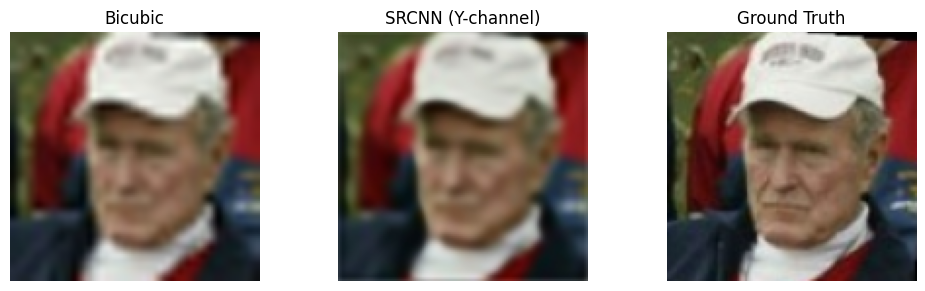

In [11]:

images_rgb, names = load_color_images(max_images=1, output_size=COLOR_Y_CONFIG["hr_size"])
if not images_rgb:
    print("Add at least one RGB image to data/input/ to run the color demo.")
else:
    img_path = next((PROJECT_ROOT / "data" / "input").glob("*.*"))
    pred_rgb = predict_color_from_file(str(img_path))
    gt_rgb = images_rgb[0]
    lr_rgb = plt.imread(str(img_path))
    import cv2
    lr_rgb = cv2.resize((gt_rgb*255).astype(np.uint8), (COLOR_Y_CONFIG["lr_size"], COLOR_Y_CONFIG["lr_size"]), interpolation=cv2.INTER_AREA)
    bicubic_rgb = cv2.resize(lr_rgb, (COLOR_Y_CONFIG["hr_size"], COLOR_Y_CONFIG["hr_size"]), interpolation=cv2.INTER_CUBIC).astype(np.float32)/255.0

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    axes[0].imshow(np.clip(bicubic_rgb, 0, 1))
    axes[0].set_title("Bicubic")
    axes[1].imshow(np.clip(pred_rgb, 0, 1))
    axes[1].set_title("SRCNN (Y-channel)")
    axes[2].imshow(np.clip(gt_rgb, 0, 1))
    axes[2].set_title("Ground Truth")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()



## 10. Interpretation and limitations

Key takeaways:
- the project demonstrates **learning-based reconstruction**, not only classification;
- grayscale SRCNN provides a clean controlled experiment;
- color reconstruction is implemented as **Y-channel super-resolution**, not full RGB reconstruction;
- interpolation baselines remain strong, especially bicubic;
- metric superiority and perceptual sharpness are not always identical.


## 11. Conclusion

This project shows how a convolutional neural network can be used for face super-resolution.

The model learns to reconstruct high-resolution images from low-resolution inputs and is compared with classical interpolation methods.

The results demonstrate that the CNN can improve visual quality, although traditional methods like bicubic interpolation can still perform well in terms of metrics.

We also explored grayscale and color (Y-channel) reconstruction, where only the luminance channel is enhanced.

Overall, the project confirms that machine learning can be effectively applied to image reconstruction problems.